# 00 — EDA on the Kaggle Mining Process Dataset

Real industrial data from a Brazilian iron-ore concentration plant. We:

1. Load the CSV (737K rows, 24 columns).
2. Inspect timestamp coverage and sampling frequency.
3. Look at sensor distributions and obvious anomalies.
4. Identify the temporal alignment between 20-second sensor data and hourly lab measurements.
5. Compute a baseline (predict the global mean of the target).

**Pre-req:** run `bash scripts/download_data.sh` first.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from frothiq.data.loader import (
    SENSOR_COLS, FEED_COLS, TARGET_COLS,
    load_flotation, temporal_split, detect_constant_lab_measurements
)

## 1. Load the dataset

In [2]:
data = load_flotation()
df = data.df
print(f'Rows: {len(df):,}')
print(f'Time range: {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Span: {(df.timestamp.max() - df.timestamp.min()).days} days')
df.head()

Rows: 737,453
Time range: 2017-03-10 01:00:00 → 2017-09-09 23:00:00
Span: 183 days


,timestamp,pct_iron_feed,pct_silica_feed,starch_flow,amina_flow,ore_pulp_flow,ore_pulp_ph,ore_pulp_density,flot_col_01_air_flow,flot_col_02_air_flow,...,flot_col_07_air_flow,flot_col_01_level,flot_col_02_level,flot_col_03_level,flot_col_04_level,flot_col_05_level,flot_col_06_level,flot_col_07_level,pct_iron_concentrate,pct_silica_concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74000,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3185.55,586.182,404.648,10.1139,1.73614,250.488,250.488,...,248.950,450.139,510.332,461.638,422.888,451.528,510.098,513.904,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3182.03,595.947,407.168,10.1135,1.73545,250.620,252.334,...,251.499,440.530,518.600,465.414,405.704,433.686,513.794,512.252,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3180.86,600.464,402.598,10.1130,1.73476,250.576,250.620,...,250.269,443.833,510.446,456.246,415.706,428.618,481.874,468.224,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,1272.66,594.971,393.516,10.1125,1.73407,250.488,249.302,...,248.511,453.242,502.968,451.604,441.878,427.296,433.372,412.824,66.91,1.31


## 2. Sampling frequency check

Sensors should be sampled every 20 seconds. Lab measurements (% Iron Concentrate, % Silica Concentrate) are hourly but forward-filled to the 20-second resolution.

In [3]:
deltas = df['timestamp'].diff().dt.total_seconds().dropna()
print('Delta-t between rows (seconds):')
print(deltas.describe())
print()
print(f'Most common delta: {deltas.mode().iloc[0]} seconds')

Delta-t between rows (seconds):
count    7.374520e+05
mean     2.154771e+01
std      1.363765e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.148400e+06
Name: timestamp, dtype: float64

Most common delta: 0.0 seconds


## 3. Distribution of sensor readings

Quick look at the central tendency and spread of each sensor.

In [4]:
df[SENSOR_COLS + FEED_COLS + TARGET_COLS].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)

,mean,std,min,50%,max
starch_flow,2869.141,1215.204,0.002,3018.430,6300.230
amina_flow,488.145,91.231,241.669,504.393,739.538
ore_pulp_flow,397.578,9.700,376.249,399.249,418.641
ore_pulp_ph,9.768,0.387,8.753,9.798,10.808
ore_pulp_density,1.680,0.069,1.520,1.698,1.853
flot_col_01_air_flow,280.152,29.621,175.510,299.344,373.871
flot_col_02_air_flow,277.160,30.149,175.156,296.223,375.992
flot_col_03_air_flow,281.082,28.558,176.469,298.696,364.346
flot_col_04_air_flow,299.448,2.573,292.195,299.805,305.871
flot_col_05_air_flow,299.918,3.637,286.295,299.887,310.270


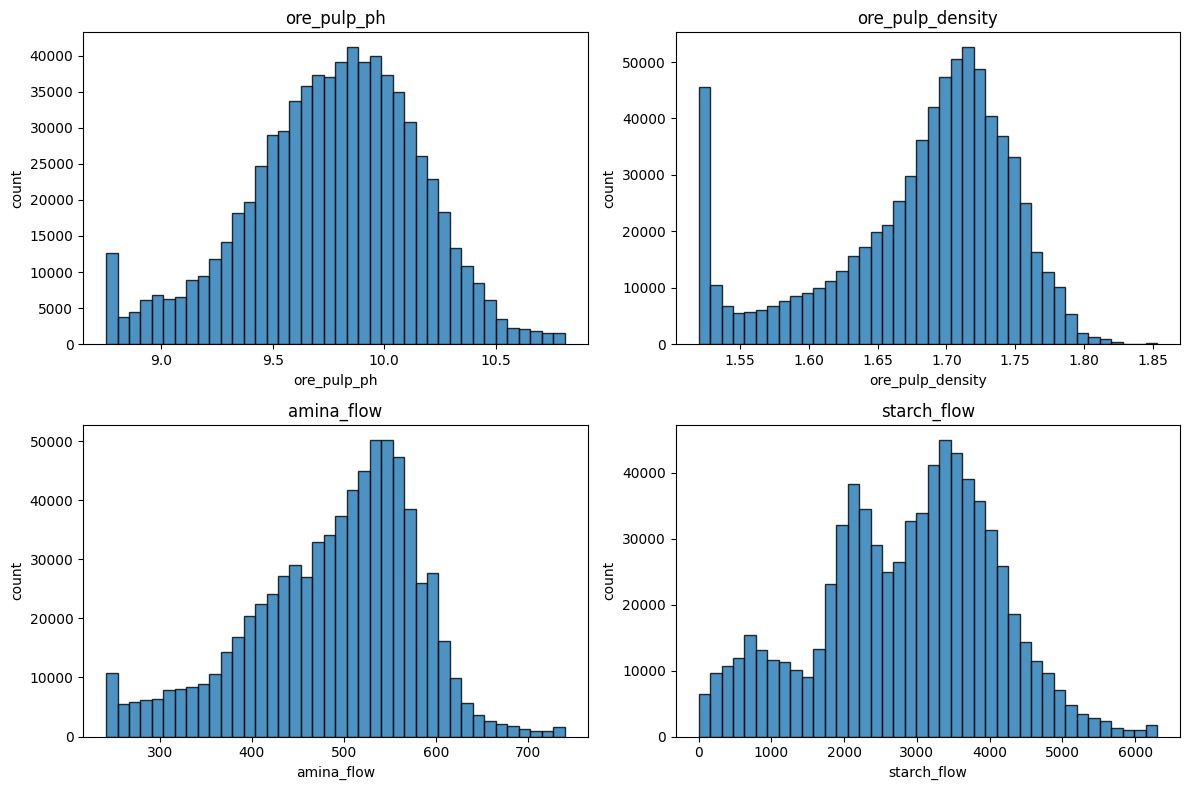

In [5]:
# Histograms of the most relevant sensors.
key_cols = ['ore_pulp_ph', 'ore_pulp_density', 'amina_flow', 'starch_flow']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, key_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor='black', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel(col); ax.set_ylabel('count')
fig.tight_layout()

## 4. Lab measurement freshness

The lab measurements are hourly but forward-filled. Identify which rows are 'fresh' (a new lab reading) vs 'stale' (forward-filled). This is critical for proper training: ideally we train only on 'fresh' rows or weight them more.

In [6]:
fresh = detect_constant_lab_measurements(df)
print(f'Total rows: {len(fresh):,}')
print(f'Fresh lab readings: {fresh.sum():,} ({100 * fresh.mean():.2f}%)')
print(f'Forward-filled rows: {(~fresh).sum():,} ({100 * (~fresh).mean():.2f}%)')

Total rows: 737,453
Fresh lab readings: 60,968 (8.27%)
Forward-filled rows: 676,485 (91.73%)


## 5. Targets over time

How does concentrate quality evolve over the dataset?

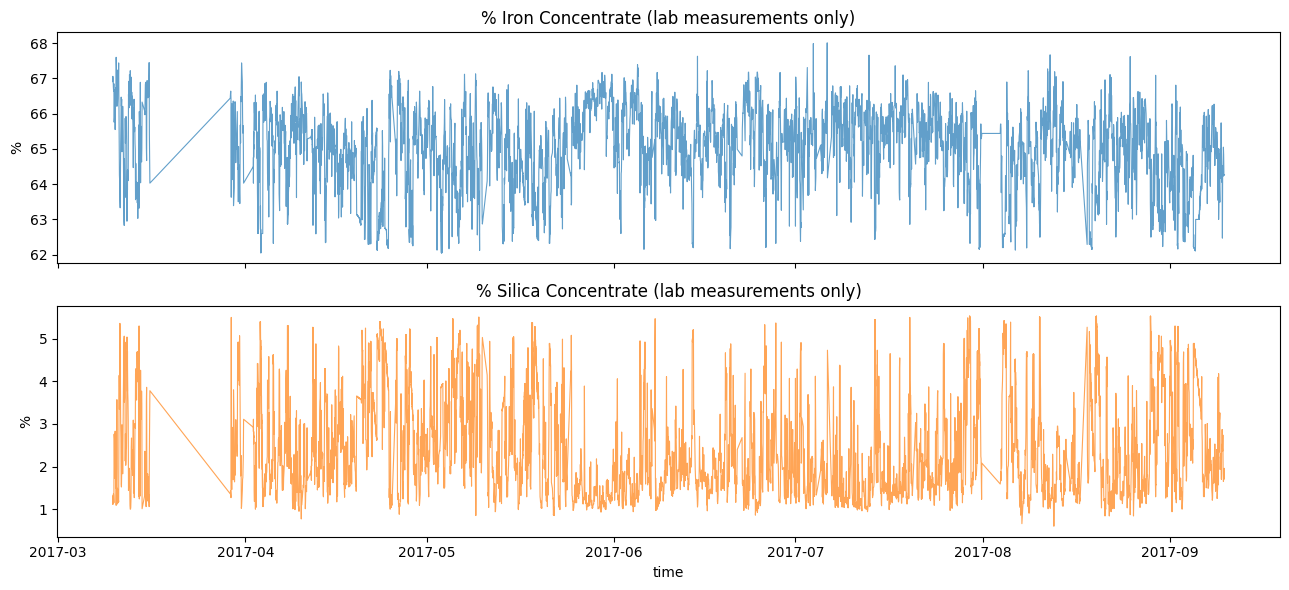

In [7]:
fresh_df = df[fresh].copy()
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(fresh_df['timestamp'], fresh_df['pct_iron_concentrate'], alpha=0.7, lw=0.8)
axes[0].set_title('% Iron Concentrate (lab measurements only)')
axes[0].set_ylabel('%')
axes[1].plot(fresh_df['timestamp'], fresh_df['pct_silica_concentrate'], alpha=0.7, lw=0.8, color='tab:orange')
axes[1].set_title('% Silica Concentrate (lab measurements only)')
axes[1].set_ylabel('%'); axes[1].set_xlabel('time')
fig.tight_layout()

## 6. Naive baseline

Predict the global mean of the target as the prediction. Anything we model later should beat this.

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train, val, test = temporal_split(df, train_frac=0.7, val_frac=0.15)

for target in TARGET_COLS:
    train_mean = train[target].mean()
    y_test = test[target].values
    y_pred = np.full_like(y_test, train_mean)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'{target}: train_mean = {train_mean:.3f}, test RMSE = {rmse:.3f}, MAE = {mae:.3f}, R² = {r2:.3f}')

pct_iron_concentrate: train_mean = 65.133, test RMSE = 1.237, MAE = 0.950, R² = -0.211
pct_silica_concentrate: train_mean = 2.317, test RMSE = 1.203, MAE = 0.993, R² = -0.009


---

## Next: `01_features.ipynb`

Feature engineering pipeline: rolling statistics over 10-min, 1-h, 3-h windows, lag features, calendar features. Persist gold table for downstream notebooks.